# Ablation Analysis
Compare retrieval and QA pipeline variants.

In [52]:
#------------Imports----------- 
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from datasets import Dataset
except ModuleNotFoundError:
    Dataset = None

In [53]:
#-------Config---------
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 3)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

BASE_DIR = Path.cwd()
RESULT_DIR = BASE_DIR / "results"

EXPERIMENTS = [
    {
        "experiment_id": "exp1",
        "experiment": "Experiment 1",
        "label": "Baseline",
        "decomposition": True,
        "broad_expansion": True,
        "path": RESULT_DIR / "experiment1.json",
    },
    {
        "experiment_id": "exp2",
        "experiment": "Experiment 2",
        "label": "No decomposition",
        "decomposition": False,
        "broad_expansion": True,
        "path": RESULT_DIR / "experiment2.json",
    },
    {
        "experiment_id": "exp3",
        "experiment": "Experiment 3",
        "label": "No broad expansion",
        "decomposition": True,
        "broad_expansion": False,
        "path": RESULT_DIR / "experiment3.json",
    },
    {
        "experiment_id": "exp4",
        "experiment": "Experiment 4",
        "label": "No decomposition + no broad expansion",
        "decomposition": False,
        "broad_expansion": False,
        "path": RESULT_DIR / "experiment4.json",
    },
]

HF_DATASET_PATHS = [
    Path.home()
    / ".cache"
    / "huggingface"
    / "datasets"
    / "hotpot_qa"
    / "fullwiki"
    / "0.0.0"
    / "1908d6afbbead072334abe2965f91bd2709910ab"
    / "hotpot_qa-validation.arrow",
    Path.home()
    / ".cache"
    / "huggingface"
    / "datasets"
    / "hotpotqa___hotpot_qa"
    / "fullwiki"
    / "0.0.0"
    / "1908d6afbbead072334abe2965f91bd2709910ab"
    / "hotpot_qa-validation.arrow",
]


In [54]:
#------------helper functions------------
def count_items(value):
    """Return length for list values; otherwise NaN."""
    if isinstance(value, list):
        return len(value)
    return np.nan


def safe_pct(delta, base):
    """Compute percentage change safely."""
    if base in (0, None) or pd.isna(base):
        return np.nan
    return 100 * delta / base


def load_supporting_titles():
    """Load HotpotQA supporting-fact titles from local cache."""
    if Dataset is None:
        print("Warning: 'datasets' is not installed; recall plots will be NaN.")
        return {}

    for dataset_path in HF_DATASET_PATHS:
        if dataset_path.exists():
            dataset = Dataset.from_file(str(dataset_path))
            return {
                row["question"]: set(row["supporting_facts"]["title"])
                for row in dataset
            }

    print("Warning: Could not find local HotpotQA validation cache; recall plots will be NaN.")
    return {}


def compute_recall(found_titles, gold_titles):
    """Compute title-level recall."""
    if not gold_titles:
        return np.nan

    found_set = {title for title in (found_titles or []) if title is not None}
    return len(found_set & gold_titles) / len(gold_titles)


def load_experiment_results(experiments):
    """Load experiment JSON files into summary and per-question DataFrames."""
    loaded = []
    records = []
    missing = []

    question_to_supporting_titles = load_supporting_titles()

    for exp in experiments:
        path = exp["path"]

        if not path.exists():
            missing.append(str(path))
            continue

        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        summary = dict(exp)
        summary.update(data.get("summary", {}))
        loaded.append(summary)

        for i, row in enumerate(data.get("records", []), start=1):
            subquestion_count = row.get("subquestion_count")
            if subquestion_count is None:
                subquestion_count = count_items(row.get("subquestions"))

            selected_count = row.get("selected_count")
            if selected_count is None:
                selected_count = count_items(row.get("selected_titles"))

            retrieved_count = row.get("retrieved_count")
            if retrieved_count is None:
                retrieved_count = count_items(row.get("retrieved_titles"))

            records.append(
                {
                    "experiment_id": exp["experiment_id"],
                    "experiment": exp["experiment"],
                    "label": exp["label"],
                    "decomposition": exp["decomposition"],
                    "broad_expansion": exp["broad_expansion"],
                    "question_id": i,
                    "question": row.get("question"),
                    "gold": row.get("gold"),
                    "prediction": row.get("prediction"),
                    "raw_answer": row.get("raw_answer"),
                    "em": row.get("em"),
                    "f1": row.get("f1"),
                    "runtime": row.get("runtime"),
                    "subquestion_count": subquestion_count,
                    "selected_count": selected_count,
                    "retrieved_count": retrieved_count,
                    "selected_titles": row.get("selected_titles"),
                    "retrieved_titles": row.get("retrieved_titles"),
                }
            )

    summary_df = pd.DataFrame(loaded)
    records_df = pd.DataFrame(records)

    if not records_df.empty:
        records_df["gold_titles"] = records_df["question"].map(
            lambda q: question_to_supporting_titles.get(q, set())
        )
        records_df["retrieval_recall"] = records_df.apply(
            lambda row: compute_recall(row["retrieved_titles"], row["gold_titles"]),
            axis=1,
        )
        records_df["evidence_recall"] = records_df.apply(
            lambda row: compute_recall(row["selected_titles"], row["gold_titles"]),
            axis=1,
        )

    if not summary_df.empty and not records_df.empty:
        summary_df = (
            records_df.groupby(
                ["experiment_id", "experiment", "label", "decomposition", "broad_expansion"],
                as_index=False,
            )
            .agg(
                examples=("question", "count"),
                exact_match=("em", "mean"),
                f1=("f1", "mean"),
                avg_runtime=("runtime", "mean"),
                total_runtime=("runtime", "sum"),
                avg_subquestions=("subquestion_count", "mean"),
                avg_selected_docs=("selected_count", "mean"),
                avg_retrieved_docs=("retrieved_count", "mean"),
                retrieval_recall=("retrieval_recall", "mean"),
                evidence_recall=("evidence_recall", "mean"),
            )
            .copy()
        )

    if not summary_df.empty:
        summary_df["decomposition"] = summary_df["decomposition"].map({True: "Yes", False: "No"})
        summary_df["broad_expansion"] = summary_df["broad_expansion"].map({True: "Yes", False: "No"})
        summary_df["avg_runtime_min"] = summary_df["avg_runtime"] / 60
        summary_df["total_runtime_min"] = summary_df["total_runtime"] / 60
        summary_df["accuracy_per_second"] = summary_df["f1"] / summary_df["avg_runtime"]

    if missing:
        print("Missing files:")
        for path in missing:
            print("-", path)

    return summary_df, records_df


def add_bar_labels(ax, values, label_fmt="{:.3f}", signed=False):
    """Add value labels above bar plots."""
    for patch, value in zip(ax.patches, values):
        if pd.isna(value):
            continue

        label = label_fmt.format(value)
        vertical_align = "bottom"
        offset = 4

        if signed and value < 0:
            vertical_align = "top"
            offset = -4

        ax.annotate(
            label,
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha="center",
            va=vertical_align,
            xytext=(0, offset),
            textcoords="offset points",
            fontsize=9,
        )


def plot_metric_bar(summary_df, metric, title, ylabel, label_fmt="{:.3f}", ylim=None):
    """Plot one metric across experiments."""
    plot_df = summary_df.dropna(subset=[metric]).sort_values("experiment")

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=plot_df,
        x="experiment",
        y=metric,
        hue="label",
        dodge=False,
        ax=ax,
    )

    if ax.legend_ is not None:
        ax.legend_.remove()

    add_bar_labels(ax, plot_df[metric], label_fmt=label_fmt)

    ax.set_title(title)
    ax.set_xlabel("Experiment")
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=20, ha="right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    if ylim is not None:
        ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.show()

In [55]:
#-------load data---------------
summary_df, records_df = load_experiment_results(EXPERIMENTS)

summary_df


,experiment_id,experiment,label,decomposition,broad_expansion,examples,exact_match,f1,avg_runtime,total_runtime,avg_subquestions,avg_selected_docs,avg_retrieved_docs,retrieval_recall,evidence_recall,avg_runtime_min,total_runtime_min,accuracy_per_second
0,exp1,Experiment 1,Baseline,Yes,Yes,50,0.34,0.485,30.969,1548.469,2.44,1.64,28.80,0.73,0.56,0.516,25.808,0.016
1,exp2,Experiment 2,No decomposition,No,Yes,50,0.34,0.446,29.069,1453.463,1.00,1.70,28.80,0.73,0.53,0.484,24.224,0.015
2,exp3,Experiment 3,No broad expansion,Yes,No,50,0.34,0.481,26.509,1325.464,2.44,1.80,28.80,0.74,0.55,0.442,22.091,0.018
3,exp4,Experiment 4,No decomposition + no broad expansion,No,No,50,0.36,0.494,23.681,1184.073,1.00,1.72,28.38,0.74,0.57,0.395,19.735,0.021


## 1. Experiment Setup
Overview of experiment configurations.

In [56]:
# experimental setup
setup_df = summary_df[
    ["experiment", "label", "decomposition", "broad_expansion", "examples"]
].copy()

setup_df

,experiment,label,decomposition,broad_expansion,examples
0,Experiment 1,Baseline,Yes,Yes,50
1,Experiment 2,No decomposition,No,Yes,50
2,Experiment 3,No broad expansion,Yes,No,50
3,Experiment 4,No decomposition + no broad expansion,No,No,50


## 2. Main Comparison Table
Summary of core evaluation metrics.

In [57]:
# main comp table
main_cols = [
    "experiment",
    "label",
    "exact_match",
    "f1",
    "retrieval_recall",
    "evidence_recall",
    "avg_runtime",
    "avg_subquestions",
    "avg_selected_docs",
    "avg_retrieved_docs",
    "total_runtime_min",
]

main_table = summary_df[main_cols].sort_values("experiment").reset_index(drop=True)

main_table.style.format(
    {
        "exact_match": "{:.3f}",
        "f1": "{:.3f}",
        "retrieval_recall": "{:.3f}",
        "evidence_recall": "{:.3f}",
        "avg_runtime": "{:.2f}s",
        "avg_subquestions": "{:.2f}",
        "avg_selected_docs": "{:.2f}",
        "avg_retrieved_docs": "{:.2f}",
        "total_runtime_min": "{:.1f} min",
    }
)



,experiment,label,exact_match,f1,retrieval_recall,evidence_recall,avg_runtime,avg_subquestions,avg_selected_docs,avg_retrieved_docs,total_runtime_min
0,Experiment 1,Baseline,0.340,0.485,0.730,0.560,30.97s,2.44,1.64,28.80,25.8 min
1,Experiment 2,No decomposition,0.340,0.446,0.730,0.530,29.07s,1.00,1.70,28.80,24.2 min
2,Experiment 3,No broad expansion,0.340,0.481,0.740,0.550,26.51s,2.44,1.80,28.80,22.1 min
3,Experiment 4,No decomposition + no broad expansion,0.360,0.494,0.740,0.570,23.68s,1.00,1.72,28.38,19.7 min


## 3. Delta vs. Baseline
Performance changes relative to Experiment 1.

In [58]:
# delta vs baseline
baseline = summary_df.loc[summary_df["experiment"] == "Experiment 1"].iloc[0]

delta_df = summary_df[
    [
        "experiment",
        "label",
        "exact_match",
        "f1",
        "avg_runtime",
        "avg_subquestions",
        "avg_selected_docs",
        "avg_retrieved_docs",
    ]
].copy()

for metric in [
    "exact_match",
    "f1",
    "avg_runtime",
    "avg_subquestions",
    "avg_selected_docs",
    "avg_retrieved_docs",
]:
    delta_df[f"{metric}_delta"] = delta_df[metric] - baseline[metric]
    delta_df[f"{metric}_pct"] = delta_df[f"{metric}_delta"].apply(
        lambda d: safe_pct(d, baseline[metric])
    )

delta_view = delta_df[
    [
        "experiment",
        "label",
        "exact_match_delta",
        "f1_delta",
        "avg_runtime_delta",
        "avg_subquestions_delta",
        "avg_selected_docs_delta",
        "avg_retrieved_docs_delta",
    ]
].copy()

delta_view.style.format(
    {
        "exact_match_delta": "{:+.3f}",
        "f1_delta": "{:+.3f}",
        "avg_runtime_delta": "{:+.2f}s",
        "avg_subquestions_delta": "{:+.2f}",
        "avg_selected_docs_delta": "{:+.2f}",
        "avg_retrieved_docs_delta": "{:+.2f}",
    }
)

,experiment,label,exact_match_delta,f1_delta,avg_runtime_delta,avg_subquestions_delta,avg_selected_docs_delta,avg_retrieved_docs_delta
0,Experiment 1,Baseline,+0.000,+0.000,+0.00s,+0.00,+0.00,+0.00
1,Experiment 2,No decomposition,+0.000,-0.039,-1.90s,-1.44,+0.06,+0.00
2,Experiment 3,No broad expansion,+0.000,-0.004,-4.46s,+0.00,+0.16,+0.00
3,Experiment 4,No decomposition + no broad expansion,+0.020,+0.009,-7.29s,-1.44,+0.08,-0.42


## 4. Summary Metric Plots
Comparison of evaluation metrics.

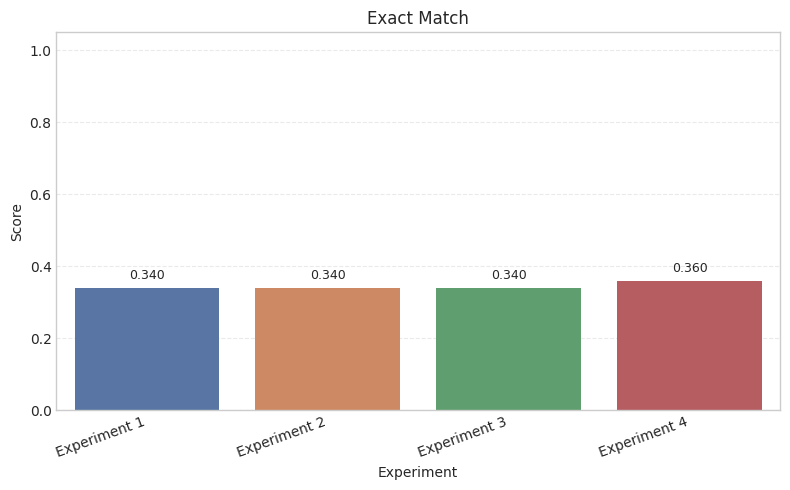

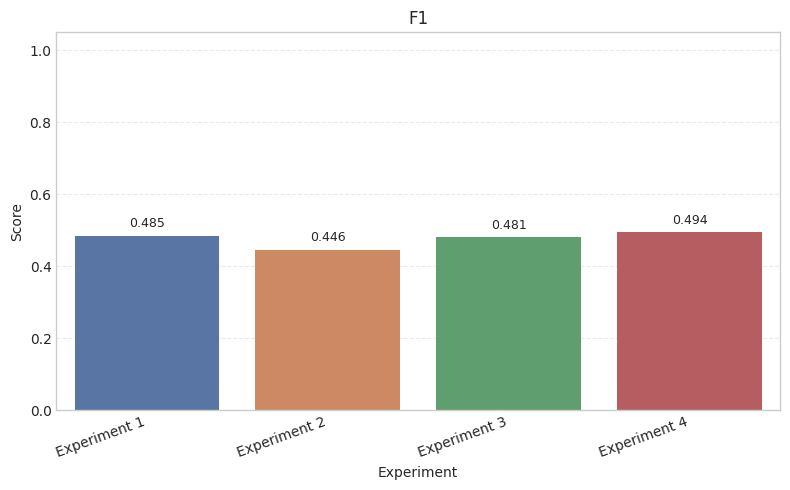

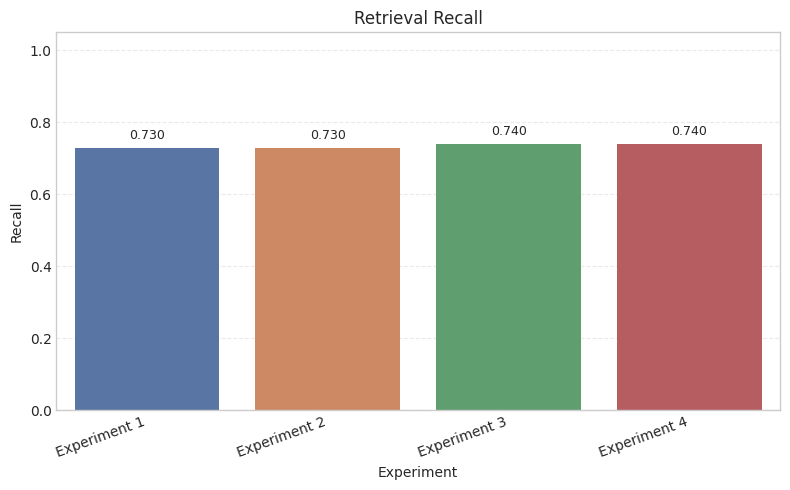

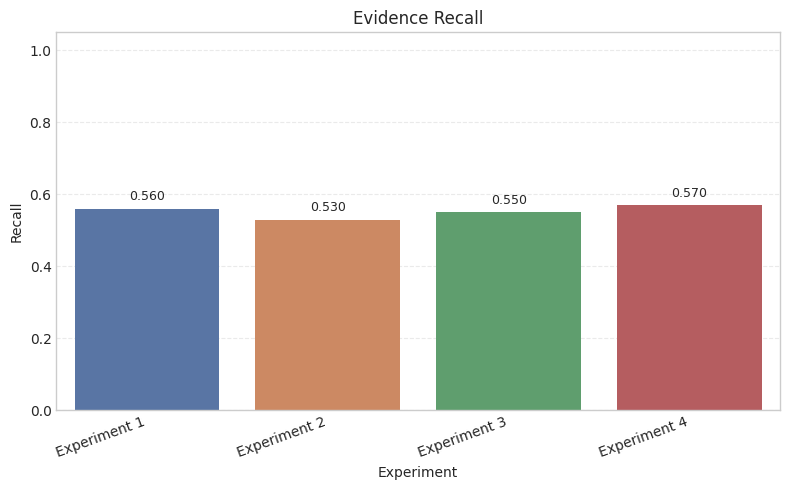

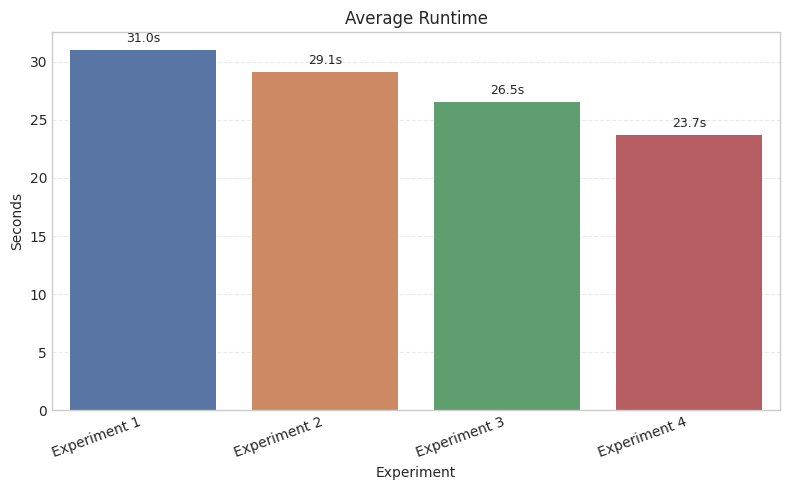

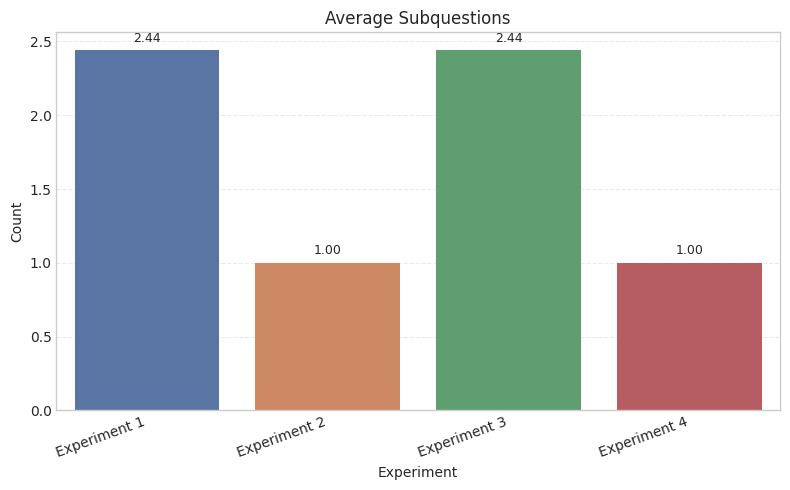

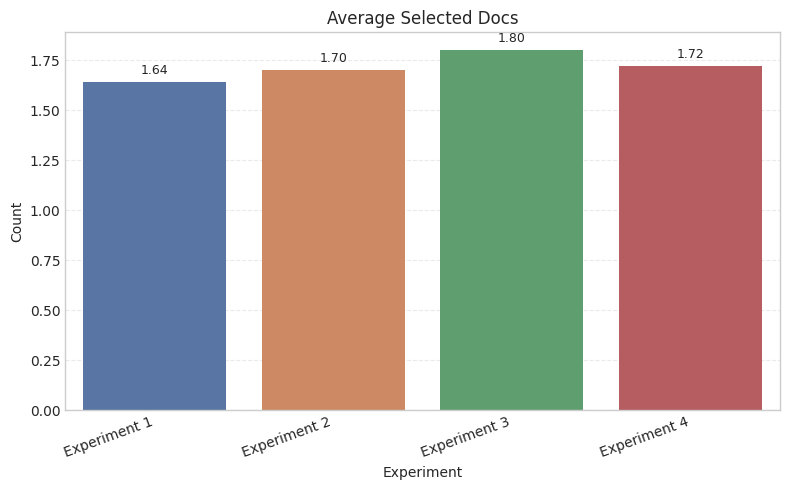

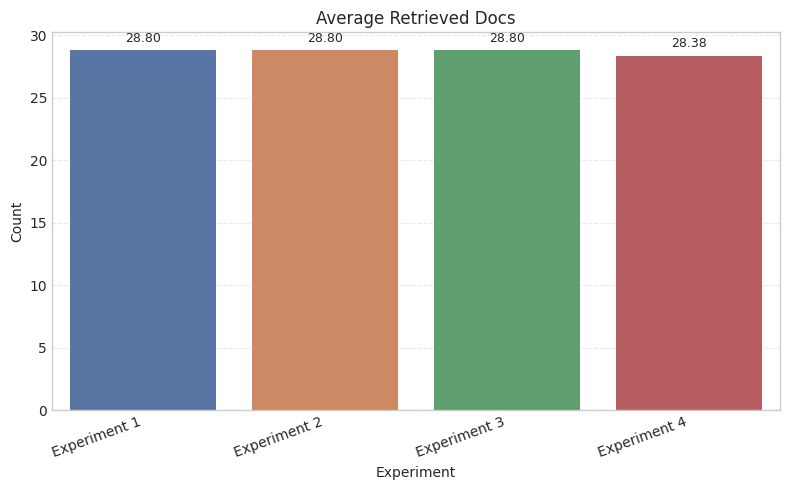

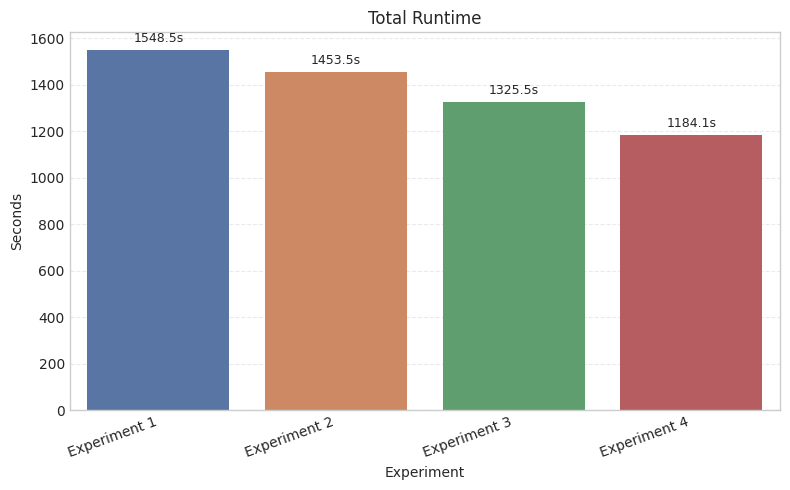

In [59]:
# metric plots
metric_specs = [
    ("exact_match", "Exact Match", "Score", "{:.3f}", (0, 1.05)),
    ("f1", "F1", "Score", "{:.3f}", (0, 1.05)),
    ("retrieval_recall", "Retrieval Recall", "Recall", "{:.3f}", (0, 1.05)),
    ("evidence_recall", "Evidence Recall", "Recall", "{:.3f}", (0, 1.05)),
    ("avg_runtime", "Average Runtime", "Seconds", "{:.1f}s", None),
    ("avg_subquestions", "Average Subquestions", "Count", "{:.2f}", None),
    ("avg_selected_docs", "Average Selected Docs", "Count", "{:.2f}", None),
    ("avg_retrieved_docs", "Average Retrieved Docs", "Count", "{:.2f}", None),
    ("total_runtime", "Total Runtime", "Seconds", "{:.1f}s", None),
]

for metric, title, ylabel, label_fmt, ylim in metric_specs:
    if metric in summary_df.columns and not summary_df[metric].isna().all():
        plot_metric_bar(summary_df, metric, title, ylabel, label_fmt, ylim)

## 5. Retrieval Recall vs. Evidence Recall
Retrieval quality versus selected evidence quality.

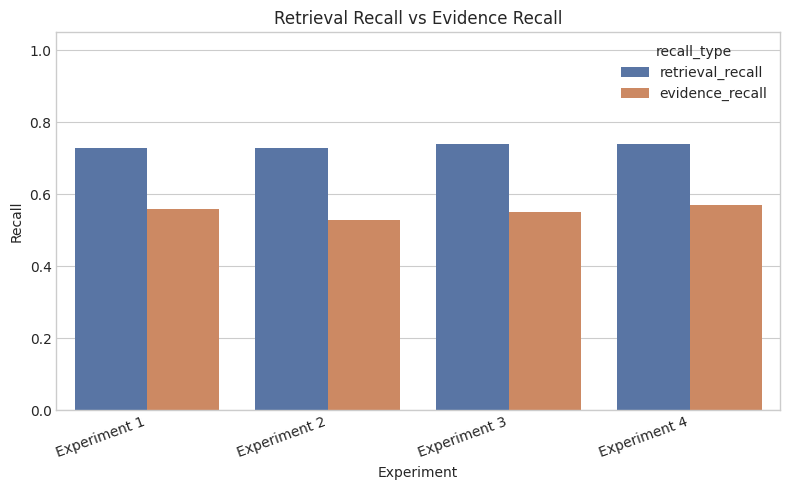

In [60]:
# retrieval recall vs evidence recall
recall_df = summary_df[["experiment", "retrieval_recall", "evidence_recall"]].melt(
    id_vars="experiment",
    var_name="recall_type",
    value_name="recall",
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=recall_df, x="experiment", y="recall", hue="recall_type", ax=ax)

ax.set_ylim(0, 1.05)
ax.set_title("Retrieval Recall vs Evidence Recall")
ax.set_ylabel("Recall")
ax.set_xlabel("Experiment")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

## 6. Component-Level Comparison
Impact of decomposition and query expansion.

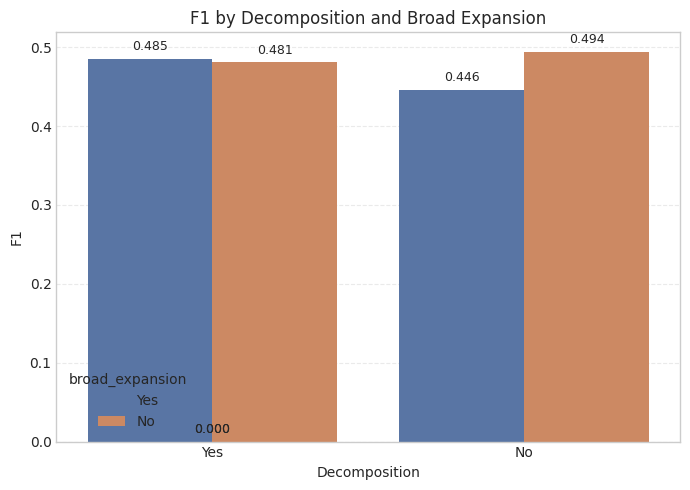

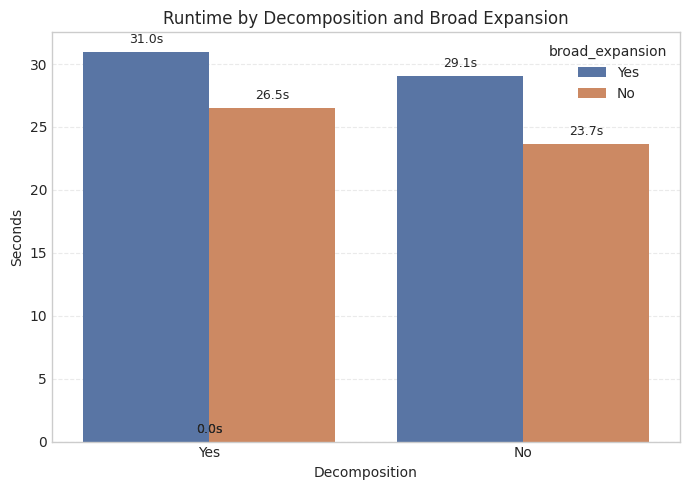

In [61]:
# component-level comparison
component_df = summary_df.copy()
component_df["decomposition"] = pd.Categorical(
    component_df["decomposition"],
    categories=["Yes", "No"],
    ordered=True,
)
component_df["broad_expansion"] = pd.Categorical(
    component_df["broad_expansion"],
    categories=["Yes", "No"],
    ordered=True,
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=component_df,
    x="decomposition",
    y="f1",
    hue="broad_expansion",
    ax=ax,
)

ax.set_title("F1 by Decomposition and Broad Expansion")
ax.set_xlabel("Decomposition")
ax.set_ylabel("F1")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
add_bar_labels(ax, [patch.get_height() for patch in ax.patches], "{:.3f}")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=component_df,
    x="decomposition",
    y="avg_runtime",
    hue="broad_expansion",
    ax=ax,
)

ax.set_title("Runtime by Decomposition and Broad Expansion")
ax.set_xlabel("Decomposition")
ax.set_ylabel("Seconds")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
add_bar_labels(ax, [patch.get_height() for patch in ax.patches], "{:.1f}s")

plt.tight_layout()
plt.show()


## 7. Automatic Interpretation
Automatic interpretation of experiment results.

In [62]:
# automatic interpretation
def variant_name(row):
    return f"{row['experiment']} ({row['label']})"


baseline = summary_df.loc[summary_df["experiment"] == "Experiment 1"].iloc[0]
exp2 = summary_df.loc[summary_df["experiment"] == "Experiment 2"].iloc[0]
exp3 = summary_df.loc[summary_df["experiment"] == "Experiment 3"].iloc[0]
exp4 = summary_df.loc[summary_df["experiment"] == "Experiment 4"].iloc[0]

print("Baseline:", variant_name(baseline))
print(
    f"- F1 = {baseline['f1']:.3f}, "
    f"EM = {baseline['exact_match']:.3f}, "
    f"avg runtime = {baseline['avg_runtime']:.2f}s"
)
print()

print("Effect of removing decomposition (Experiment 2 vs Experiment 1):")
print(f"- F1 delta: {exp2['f1'] - baseline['f1']:+.3f}")
print(f"- EM delta: {exp2['exact_match'] - baseline['exact_match']:+.3f}")
print(f"- Runtime delta: {exp2['avg_runtime'] - baseline['avg_runtime']:+.2f}s")
print(f"- Subquestion delta: {exp2['avg_subquestions'] - baseline['avg_subquestions']:+.2f}")
print()

print("Effect of removing broad expansion (Experiment 3 vs Experiment 1):")
print(f"- F1 delta: {exp3['f1'] - baseline['f1']:+.3f}")
print(f"- EM delta: {exp3['exact_match'] - baseline['exact_match']:+.3f}")
print(f"- Runtime delta: {exp3['avg_runtime'] - baseline['avg_runtime']:+.2f}s")
print(f"- Retrieved-doc delta: {exp3['avg_retrieved_docs'] - baseline['avg_retrieved_docs']:+.2f}")
print()

print("Effect of removing both (Experiment 4 vs Experiment 1):")
print(f"- F1 delta: {exp4['f1'] - baseline['f1']:+.3f}")
print(f"- EM delta: {exp4['exact_match'] - baseline['exact_match']:+.3f}")
print(f"- Runtime delta: {exp4['avg_runtime'] - baseline['avg_runtime']:+.2f}s")
print(f"- Subquestion delta: {exp4['avg_subquestions'] - baseline['avg_subquestions']:+.2f}")
print()

winner = summary_df.sort_values(["f1", "avg_runtime"], ascending=[False, True]).iloc[0]
print("Overall recommendation:")
print(
    f"- Best trade-off in this run: {variant_name(winner)} "
    f"with F1 {winner['f1']:.3f} and avg runtime {winner['avg_runtime']:.2f}s"
)


Baseline: Experiment 1 (Baseline)
- F1 = 0.485, EM = 0.340, avg runtime = 30.97s

Effect of removing decomposition (Experiment 2 vs Experiment 1):
- F1 delta: -0.039
- EM delta: +0.000
- Runtime delta: -1.90s
- Subquestion delta: -1.44

Effect of removing broad expansion (Experiment 3 vs Experiment 1):
- F1 delta: -0.004
- EM delta: +0.000
- Runtime delta: -4.46s
- Retrieved-doc delta: +0.00

Effect of removing both (Experiment 4 vs Experiment 1):
- F1 delta: +0.009
- EM delta: +0.020
- Runtime delta: -7.29s
- Subquestion delta: -1.44

Overall recommendation:
- Best trade-off in this run: Experiment 4 (No decomposition + no broad expansion) with F1 0.494 and avg runtime 23.68s


## 8. Runtime Analysis
Runtime distribution and efficiency analysis.

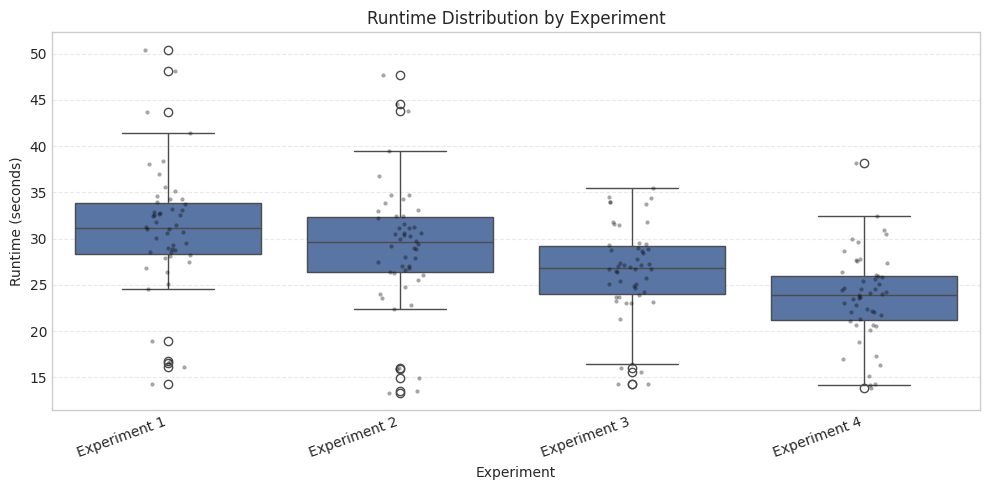

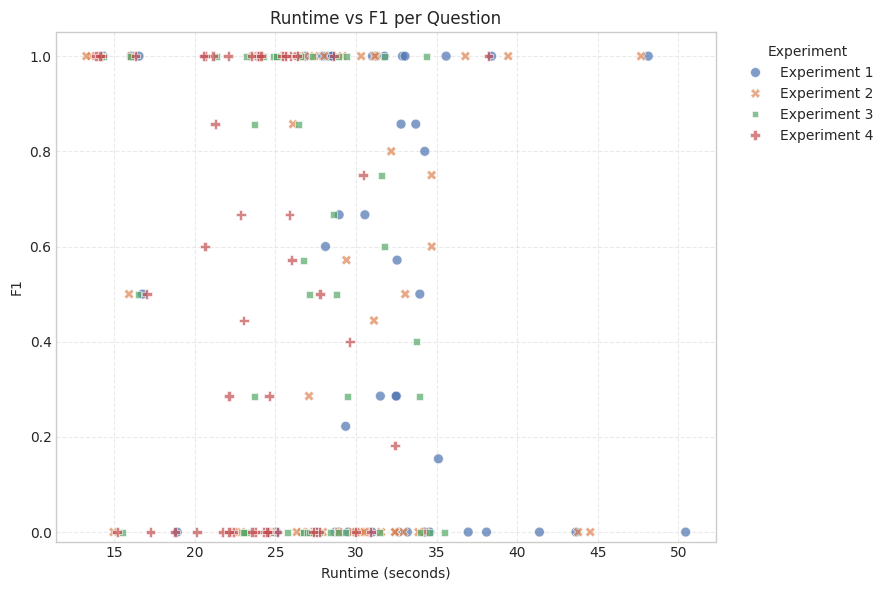

In [63]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=records_df, x="experiment", y="runtime", ax=ax)
sns.stripplot(
    data=records_df,
    x="experiment",
    y="runtime",
    color="black",
    alpha=0.35,
    size=3,
    ax=ax,
)

ax.set_title("Runtime Distribution by Experiment")
ax.set_xlabel("Experiment")
ax.set_ylabel("Runtime (seconds)")
plt.xticks(rotation=20, ha="right")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=records_df,
    x="runtime",
    y="f1",
    hue="experiment",
    style="experiment",
    s=50,
    alpha=0.7,
    ax=ax,
)

ax.set_title("Runtime vs F1 per Question")
ax.set_xlabel("Runtime (seconds)")
ax.set_ylabel("F1")
ax.set_ylim(-0.02, 1.05)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(title="Experiment", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


## 9. Error Analysis Candidates
Low-performing examples for inspection.

In [64]:
error_candidates = records_df.sort_values(["f1", "runtime"], ascending=[True, False])

display(
    error_candidates[
        [
            "experiment",
            "question_id",
            "question",
            "gold",
            "prediction",
            "f1",
            "runtime",
            "subquestion_count",
            "selected_count",
            "retrieved_count",
        ]
    ].head(20)
)


,experiment,question_id,question,gold,prediction,f1,runtime,subquestion_count,selected_count,retrieved_count
29,Experiment 1,30,"What is the name for the adventure in ""Tunnels and Trolls"", a game designed by Ken St. Andre?",Arena of Khazan,"The adventure in ""Tunnels and Trolls",0.0,50.449,3,2,30
79,Experiment 2,30,"What is the name for the adventure in ""Tunnels and Trolls"", a game designed by Ken St. Andre?",Arena of Khazan,Not Answerable,0.0,44.533,1,2,30
50,Experiment 2,1,Were Scott Derrickson and Ed Wood of the same nationality?,yes,no,0.0,43.781,1,2,30
0,Experiment 1,1,Were Scott Derrickson and Ed Wood of the same nationality?,yes,no,0.0,43.645,3,2,30
49,Experiment 1,50,Which British first-generation jet-powered medium bomber was used in the South West Pacific theatre of World War II?,English Electric Canberra,The British first-generation jet-powered medium bomber used in the South West Pacific theatre of World War II was th...,0.0,41.383,4,1,30
26,Experiment 1,27,"The 2011–12 VCU Rams men's basketball team, led by third year head coach Shaka Smart, represented Virginia Commonwea...",1838,Virginia Commonwealth University was founded in not specified in the evidence.,0.0,38.100,4,2,30
4,Experiment 1,5,"The director of the romantic comedy ""Big Stone Gap"" is based in what New York city?","Greenwich Village, New York City",Not Answerable,0.0,36.965,3,2,30
118,Experiment 3,19,Roger O. Egeberg was Assistant Secretary for Health and Scientific Affairs during the administration of a president ...,1969 until 1974,Richard Nixon,0.0,35.490,4,2,30
30,Experiment 1,31,"When was Poison's album ""Shut Up, Make Love"" released?",2000,"March 14, 200",0.0,34.575,4,2,30
129,Experiment 3,30,"What is the name for the adventure in ""Tunnels and Trolls"", a game designed by Ken St. Andre?",Arena of Khazan,The adventure is called 'Tunnels & Trolls'.,0.0,34.536,3,2,30
